In [2]:
! pip install numpy matplotlib pandas scikit-learn gymnasium

1. Implement a simple Grid-World environment and train an agent using Q-Learning


In [3]:
import numpy as np
import random
import time

# =========================
# Grid World Environment
# =========================

class GridWorld:
    def __init__(self, size=5):
        self.size = size

        # Actions
        # 0 = Up, 1 = Down, 2 = Left, 3 = Right
        self.actions = [0, 1, 2, 3]

        # Start and Goal
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)

        # Obstacles (optional)
        self.obstacles = [(1, 1), (2, 2), (3, 1)]

        self.reset()

    def reset(self):
        self.agent_pos = self.start
        return self.agent_pos

    def step(self, action):
        x, y = self.agent_pos

        # Move agent
        if action == 0:   # Up
            x = max(x - 1, 0)
        elif action == 1: # Down
            x = min(x + 1, self.size - 1)
        elif action == 2: # Left
            y = max(y - 1, 0)
        elif action == 3: # Right
            y = min(y + 1, self.size - 1)

        next_state = (x, y)

        # Obstacle penalty
        if next_state in self.obstacles:
            reward = -10
            next_state = self.agent_pos

        # Goal reward
        elif next_state == self.goal:
            reward = 100

        # Normal movement penalty
        else:
            reward = -1

        self.agent_pos = next_state

        done = next_state == self.goal

        return next_state, reward, done

    def render(self):
        grid = np.full((self.size, self.size), '-')

        for obs in self.obstacles:
            grid[obs] = 'X'

        grid[self.goal] = 'G'
        grid[self.agent_pos] = 'A'

        print(grid)
        print()


# =========================
# Q-Learning Agent
# =========================

class QLearningAgent:
    def __init__(
        self,
        env,
        alpha=0.1,
        gamma=0.9,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.01
    ):

        self.env = env
        self.alpha = alpha      # Learning rate
        self.gamma = gamma      # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-table
        self.q_table = {}

        # Initialize Q-values
        for x in range(env.size):
            for y in range(env.size):
                self.q_table[(x, y)] = np.zeros(len(env.actions))

    def choose_action(self, state):

        # Exploration
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.env.actions)

        # Exploitation
        return np.argmax(self.q_table[state])

    def learn(self, state, action, reward, next_state):

        current_q = self.q_table[state][action]

        max_future_q = np.max(self.q_table[next_state])

        # Q-Learning formula
        new_q = current_q + self.alpha * (
            reward + self.gamma * max_future_q - current_q
        )

        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


# =========================
# Training
# =========================

env = GridWorld(size=5)
agent = QLearningAgent(env)

episodes = 500

for episode in range(episodes):

    state = env.reset()
    done = False
    total_reward = 0

    while not done:

        action = agent.choose_action(state)

        next_state, reward, done = env.step(action)

        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    agent.decay_epsilon()

    if (episode + 1) % 50 == 0:
        print(
            f"Episode {episode+1}, "
            f"Total Reward: {total_reward}, "
            f"Epsilon: {agent.epsilon:.3f}"
        )


# =========================
# Test the Trained Agent
# =========================

print("\nTesting trained agent...\n")

state = env.reset()
done = False

env.render()
time.sleep(1)

while not done:

    action = np.argmax(agent.q_table[state])

    next_state, reward, done = env.step(action)

    state = next_state

    env.render()
    time.sleep(0.5)

print("Goal reached!")

Episode 50, Total Reward: -78, Epsilon: 0.778
Episode 100, Total Reward: 89, Epsilon: 0.606
Episode 150, Total Reward: 46, Epsilon: 0.471
Episode 200, Total Reward: 73, Epsilon: 0.367
Episode 250, Total Reward: 71, Epsilon: 0.286
Episode 300, Total Reward: 93, Epsilon: 0.222
Episode 350, Total Reward: 91, Epsilon: 0.173
Episode 400, Total Reward: 93, Epsilon: 0.135
Episode 450, Total Reward: 87, Epsilon: 0.105
Episode 500, Total Reward: 93, Epsilon: 0.082

Testing trained agent...

[['A' '-' '-' '-' '-']
 ['-' 'X' '-' '-' '-']
 ['-' '-' 'X' '-' '-']
 ['-' 'X' '-' '-' '-']
 ['-' '-' '-' '-' 'G']]

[['-' '-' '-' '-' '-']
 ['A' 'X' '-' '-' '-']
 ['-' '-' 'X' '-' '-']
 ['-' 'X' '-' '-' '-']
 ['-' '-' '-' '-' 'G']]

[['-' '-' '-' '-' '-']
 ['-' 'X' '-' '-' '-']
 ['A' '-' 'X' '-' '-']
 ['-' 'X' '-' '-' '-']
 ['-' '-' '-' '-' 'G']]

[['-' '-' '-' '-' '-']
 ['-' 'X' '-' '-' '-']
 ['-' '-' 'X' '-' '-']
 ['A' 'X' '-' '-' '-']
 ['-' '-' '-' '-' 'G']]

[['-' '-' '-' '-' '-']
 ['-' 'X' '-' '-' '-']

2. Implement multi-armed bandit problem and compare E-greedy, UCB, and SoftMax strategies

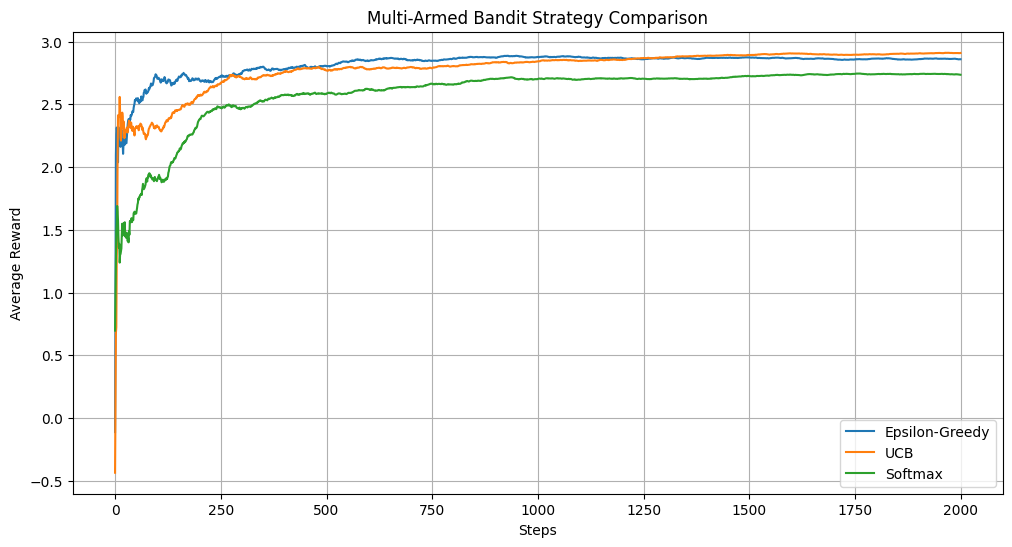


Final Average Rewards:

Epsilon-Greedy: 2.860
UCB:             2.910
Softmax:         2.736

Best Arm:
Arm 3 with mean reward 3.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Multi-Armed Bandit Environment
# ==========================================

class MultiArmedBandit:
    def __init__(self, true_means):
        """
        true_means: actual reward mean for each arm
        """
        self.true_means = true_means
        self.n_arms = len(true_means)

    def pull(self, arm):
        """
        Returns stochastic reward from selected arm
        """
        return np.random.normal(self.true_means[arm], 1.0)


# ==========================================
# Base Agent
# ==========================================

class BaseAgent:
    def __init__(self, n_arms):
        self.n_arms = n_arms

        self.q_values = np.zeros(n_arms)
        self.action_counts = np.zeros(n_arms)

        self.total_reward = 0

    def update(self, arm, reward):
        self.action_counts[arm] += 1

        n = self.action_counts[arm]

        # Incremental mean update
        self.q_values[arm] += (reward - self.q_values[arm]) / n

        self.total_reward += reward


# ==========================================
# Epsilon-Greedy Agent
# ==========================================

class EpsilonGreedyAgent(BaseAgent):
    def __init__(self, n_arms, epsilon=0.1):
        super().__init__(n_arms)
        self.epsilon = epsilon

    def select_action(self):

        # Explore
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_arms)

        # Exploit
        return np.argmax(self.q_values)


# ==========================================
# UCB Agent
# ==========================================

class UCBAgent(BaseAgent):
    def __init__(self, n_arms, c=2):
        super().__init__(n_arms)
        self.c = c
        self.total_steps = 0

    def select_action(self):

        self.total_steps += 1

        # Ensure every arm selected once
        for arm in range(self.n_arms):
            if self.action_counts[arm] == 0:
                return arm

        ucb_values = self.q_values + self.c * np.sqrt(
            np.log(self.total_steps) / self.action_counts
        )

        return np.argmax(ucb_values)


# ==========================================
# Softmax Agent
# ==========================================

class SoftmaxAgent(BaseAgent):
    def __init__(self, n_arms, temperature=0.5):
        super().__init__(n_arms)
        self.temperature = temperature

    def select_action(self):

        # Softmax probabilities
        exp_values = np.exp(self.q_values / self.temperature)

        probabilities = exp_values / np.sum(exp_values)

        return np.random.choice(self.n_arms, p=probabilities)


# ==========================================
# Simulation Function
# ==========================================

def run_experiment(agent, bandit, steps=1000):

    rewards = []

    for _ in range(steps):

        arm = agent.select_action()

        reward = bandit.pull(arm)

        agent.update(arm, reward)

        rewards.append(reward)

    return np.cumsum(rewards) / (np.arange(steps) + 1)


# ==========================================
# Main Experiment
# ==========================================

np.random.seed(42)

# True reward means for 5 slot machines
true_means = [1.0, 2.0, 1.5, 3.0, 2.5]

bandit = MultiArmedBandit(true_means)

steps = 2000

# Create agents
epsilon_agent = EpsilonGreedyAgent(n_arms=5, epsilon=0.1)
ucb_agent = UCBAgent(n_arms=5, c=2)
softmax_agent = SoftmaxAgent(n_arms=5, temperature=0.5)

# Run experiments
epsilon_rewards = run_experiment(epsilon_agent, bandit, steps)
ucb_rewards = run_experiment(ucb_agent, bandit, steps)
softmax_rewards = run_experiment(softmax_agent, bandit, steps)

# ==========================================
# Plot Results
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(epsilon_rewards, label="Epsilon-Greedy")
plt.plot(ucb_rewards, label="UCB")
plt.plot(softmax_rewards, label="Softmax")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Multi-Armed Bandit Strategy Comparison")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# Final Statistics
# ==========================================

print("\nFinal Average Rewards:\n")

print(f"Epsilon-Greedy: {epsilon_rewards[-1]:.3f}")
print(f"UCB:             {ucb_rewards[-1]:.3f}")
print(f"Softmax:         {softmax_rewards[-1]:.3f}")

print("\nBest Arm:")
print(f"Arm {np.argmax(true_means)} with mean reward {max(true_means)}")

3. Model a drone delivery environment as a Markov Decision Process (MDP) accounting for probabilistic transitions and battery constraints, and solve it using both Policy Iteration and Value Iteration to determine the most efficient delivery route.



In [5]:
import numpy as np

# ==========================================
# Drone Delivery MDP Environment
# ==========================================

class DroneMDP:

    def __init__(self, grid_size=5, battery_levels=10):

        self.grid_size = grid_size
        self.battery_levels = battery_levels

        self.actions = ["UP", "DOWN", "LEFT", "RIGHT"]

        self.action_map = {
            "UP": (-1, 0),
            "DOWN": (1, 0),
            "LEFT": (0, -1),
            "RIGHT": (0, 1)
        }

        self.start = (0, 0)
        self.goal = (4, 4)

        self.obstacles = [(1, 2), (2, 2), (3, 1)]

        self.gamma = 0.95

        self.states = []

        # State = (x, y, battery)
        for x in range(grid_size):
            for y in range(grid_size):
                for b in range(battery_levels + 1):
                    self.states.append((x, y, b))

    # --------------------------------------
    # Terminal state check
    # --------------------------------------

    def is_terminal(self, state):

        x, y, b = state

        return (
            (x, y) == self.goal
            or b == 0
        )

    # --------------------------------------
    # Transition Model
    # --------------------------------------

    def get_transitions(self, state, action):

        if self.is_terminal(state):
            return [(1.0, state, 0)]

        x, y, battery = state

        battery -= 1

        transitions = []

        intended_move = self.action_map[action]

        drift_actions = self.get_drift_actions(action)

        possible_moves = [
            (0.8, intended_move),
            (0.1, self.action_map[drift_actions[0]]),
            (0.1, self.action_map[drift_actions[1]])
        ]

        for prob, move in possible_moves:

            nx = min(max(x + move[0], 0), self.grid_size - 1)
            ny = min(max(y + move[1], 0), self.grid_size - 1)

            reward = -1

            # Obstacle penalty
            if (nx, ny) in self.obstacles:
                reward = -20
                nx, ny = x, y

            # Goal reward
            elif (nx, ny) == self.goal:
                reward = 100

            # Battery exhausted
            if battery <= 0 and (nx, ny) != self.goal:
                reward = -100

            next_state = (nx, ny, max(battery, 0))

            transitions.append(
                (prob, next_state, reward)
            )

        return transitions

    # --------------------------------------
    # Drift Model
    # --------------------------------------

    def get_drift_actions(self, action):

        if action in ["UP", "DOWN"]:
            return ["LEFT", "RIGHT"]

        return ["UP", "DOWN"]


# ==========================================
# Value Iteration
# ==========================================

def value_iteration(env, theta=1e-5):

    V = {s: 0 for s in env.states}

    while True:

        delta = 0

        for state in env.states:

            if env.is_terminal(state):
                continue

            old_v = V[state]

            action_values = []

            for action in env.actions:

                value = 0

                for prob, next_state, reward in env.get_transitions(state, action):

                    value += prob * (
                        reward + env.gamma * V[next_state]
                    )

                action_values.append(value)

            V[state] = max(action_values)

            delta = max(delta, abs(old_v - V[state]))

        if delta < theta:
            break

    # Extract policy
    policy = {}

    for state in env.states:

        if env.is_terminal(state):
            policy[state] = None
            continue

        best_action = None
        best_value = float("-inf")

        for action in env.actions:

            value = 0

            for prob, next_state, reward in env.get_transitions(state, action):

                value += prob * (
                    reward + env.gamma * V[next_state]
                )

            if value > best_value:
                best_value = value
                best_action = action

        policy[state] = best_action

    return V, policy


# ==========================================
# Policy Iteration
# ==========================================

def policy_iteration(env, theta=1e-5):

    policy = {
        s: np.random.choice(env.actions)
        if not env.is_terminal(s)
        else None
        for s in env.states
    }

    V = {s: 0 for s in env.states}

    while True:

        # ----------------------------------
        # Policy Evaluation
        # ----------------------------------

        while True:

            delta = 0

            for state in env.states:

                if env.is_terminal(state):
                    continue

                old_v = V[state]

                action = policy[state]

                value = 0

                for prob, next_state, reward in env.get_transitions(state, action):

                    value += prob * (
                        reward + env.gamma * V[next_state]
                    )

                V[state] = value

                delta = max(delta, abs(old_v - value))

            if delta < theta:
                break

        # ----------------------------------
        # Policy Improvement
        # ----------------------------------

        stable = True

        for state in env.states:

            if env.is_terminal(state):
                continue

            old_action = policy[state]

            best_action = None
            best_value = float("-inf")

            for action in env.actions:

                value = 0

                for prob, next_state, reward in env.get_transitions(state, action):

                    value += prob * (
                        reward + env.gamma * V[next_state]
                    )

                if value > best_value:
                    best_value = value
                    best_action = action

            policy[state] = best_action

            if best_action != old_action:
                stable = False

        if stable:
            break

    return V, policy


# ==========================================
# Run Both Algorithms
# ==========================================

env = DroneMDP()

print("Running Value Iteration...")
V_vi, policy_vi = value_iteration(env)

print("Running Policy Iteration...")
V_pi, policy_pi = policy_iteration(env)

# ==========================================
# Show Optimal Route
# ==========================================

def simulate_policy(env, policy):

    state = (0, 0, 10)

    route = []

    while not env.is_terminal(state):

        route.append(state)

        action = policy[state]

        transitions = env.get_transitions(state, action)

        # Choose most probable transition
        next_state = max(transitions, key=lambda x: x[0])[1]

        state = next_state

    route.append(state)

    return route

route_vi = simulate_policy(env, policy_vi)
route_pi = simulate_policy(env, policy_pi)

print("\nOptimal Route from Value Iteration:")
for r in route_vi:
    print(r)

print("\nOptimal Route from Policy Iteration:")
for r in route_pi:
    print(r)

Running Value Iteration...
Running Policy Iteration...

Optimal Route from Value Iteration:
(0, 0, 10)
(0, 1, 9)
(0, 2, 8)
(0, 3, 7)
(1, 3, 6)
(2, 3, 5)
(3, 3, 4)
(3, 4, 3)
(4, 4, 2)

Optimal Route from Policy Iteration:
(0, 0, 10)
(0, 1, 9)
(0, 2, 8)
(0, 3, 7)
(1, 3, 6)
(2, 3, 5)
(3, 3, 4)
(3, 4, 3)
(4, 4, 2)


4. Apply Policy Evaluation and Policy Improvement techniques on a small financial MDP to evaluate an existing trading strategy and iteratively derive an improved policy that maximizes long-term returns for an Al-based financial advisor.

In [6]:
import numpy as np

# ==========================================
# Financial Trading MDP
# ==========================================

class FinancialMDP:

    def __init__(self):

        self.states = ["Bull", "Bear", "Stable"]

        self.actions = ["Buy", "Sell", "Hold"]

        self.gamma = 0.9

        # ----------------------------------
        # Transition Probabilities
        # P[s][a] -> list of (prob, next_state)
        # ----------------------------------

        self.transitions = {

            "Bull": {
                "Buy": [
                    (0.7, "Bull"),
                    (0.1, "Bear"),
                    (0.2, "Stable")
                ],
                "Sell": [
                    (0.6, "Bull"),
                    (0.2, "Bear"),
                    (0.2, "Stable")
                ],
                "Hold": [
                    (0.65, "Bull"),
                    (0.15, "Bear"),
                    (0.2, "Stable")
                ]
            },

            "Bear": {
                "Buy": [
                    (0.2, "Bull"),
                    (0.6, "Bear"),
                    (0.2, "Stable")
                ],
                "Sell": [
                    (0.25, "Bull"),
                    (0.55, "Bear"),
                    (0.2, "Stable")
                ],
                "Hold": [
                    (0.2, "Bull"),
                    (0.5, "Bear"),
                    (0.3, "Stable")
                ]
            },

            "Stable": {
                "Buy": [
                    (0.4, "Bull"),
                    (0.2, "Bear"),
                    (0.4, "Stable")
                ],
                "Sell": [
                    (0.3, "Bull"),
                    (0.3, "Bear"),
                    (0.4, "Stable")
                ],
                "Hold": [
                    (0.35, "Bull"),
                    (0.25, "Bear"),
                    (0.4, "Stable")
                ]
            }
        }

        # ----------------------------------
        # Reward Function
        # ----------------------------------

        self.rewards = {

            ("Bull", "Buy"): 10,
            ("Bull", "Sell"): -2,
            ("Bull", "Hold"): 4,

            ("Bear", "Buy"): -8,
            ("Bear", "Sell"): 6,
            ("Bear", "Hold"): 1,

            ("Stable", "Buy"): 3,
            ("Stable", "Sell"): 1,
            ("Stable", "Hold"): 3
        }

    # --------------------------------------
    # Get reward
    # --------------------------------------

    def get_reward(self, state, action):

        return self.rewards[(state, action)]


# ==========================================
# Policy Evaluation
# ==========================================

def policy_evaluation(env, policy, theta=1e-5):

    V = {s: 0 for s in env.states}

    while True:

        delta = 0

        for state in env.states:

            old_v = V[state]

            action = policy[state]

            new_v = 0

            for prob, next_state in env.transitions[state][action]:

                reward = env.get_reward(state, action)

                new_v += prob * (
                    reward + env.gamma * V[next_state]
                )

            V[state] = new_v

            delta = max(delta, abs(old_v - new_v))

        if delta < theta:
            break

    return V


# ==========================================
# Policy Improvement
# ==========================================

def policy_improvement(env, V):

    policy = {}

    for state in env.states:

        best_action = None
        best_value = float("-inf")

        for action in env.actions:

            value = 0

            for prob, next_state in env.transitions[state][action]:

                reward = env.get_reward(state, action)

                value += prob * (
                    reward + env.gamma * V[next_state]
                )

            if value > best_value:
                best_value = value
                best_action = action

        policy[state] = best_action

    return policy


# ==========================================
# Policy Iteration
# ==========================================

def policy_iteration(env):

    # Initial random policy
    policy = {
        "Bull": "Hold",
        "Bear": "Hold",
        "Stable": "Hold"
    }

    iteration = 0

    while True:

        iteration += 1

        print(f"\nIteration {iteration}")

        # ------------------------------
        # Policy Evaluation
        # ------------------------------

        V = policy_evaluation(env, policy)

        print("\nState Values:")

        for s, v in V.items():
            print(f"{s}: {v:.2f}")

        # ------------------------------
        # Policy Improvement
        # ------------------------------

        new_policy = policy_improvement(env, V)

        print("\nImproved Policy:")

        for s, a in new_policy.items():
            print(f"{s}: {a}")

        # Check convergence
        if new_policy == policy:
            print("\nPolicy converged.")
            break

        policy = new_policy

    return policy, V


# ==========================================
# Run Financial Policy Iteration
# ==========================================

env = FinancialMDP()

optimal_policy, optimal_values = policy_iteration(env)

# ==========================================
# Final Results
# ==========================================

print("\n==============================")
print("Optimal Trading Policy")
print("==============================")

for state, action in optimal_policy.items():
    print(f"{state}: {action}")

print("\n==============================")
print("Optimal State Values")
print("==============================")

for state, value in optimal_values.items():
    print(f"{state}: {value:.2f}")


Iteration 1

State Values:
Bull: 30.68
Bear: 26.07
Stable: 28.95

Improved Policy:
Bull: Buy
Bear: Sell
Stable: Buy

Iteration 2

State Values:
Bull: 77.26
Bear: 70.53
Stable: 67.98

Improved Policy:
Bull: Buy
Bear: Sell
Stable: Buy

Policy converged.

Optimal Trading Policy
Bull: Buy
Bear: Sell
Stable: Buy

Optimal State Values
Bull: 77.26
Bear: 70.53
Stable: 67.98


5. Implement Monte Carlo Prediction to estimate the state-value function and Monte Carlo Control with an £-greedy policy to find the optimal policy for a Blackjack environment.

In [7]:
import gymnasium as gym
import numpy as np
from collections import defaultdict

# ==========================================
# Blackjack Environment
# ==========================================

env = gym.make("Blackjack-v1")

# Actions:
# 0 = Stick
# 1 = Hit

# ==========================================
# Monte Carlo Prediction
# ==========================================

def mc_prediction(policy, env, episodes=500000, gamma=1.0):

    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)

    V = defaultdict(float)

    for episode in range(episodes):

        episode_data = []

        state, _ = env.reset()

        done = False

        # Generate episode
        while not done:

            action = policy(state)

            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            episode_data.append((state, reward))

            state = next_state

        # First-Visit Monte Carlo
        G = 0
        visited_states = set()

        for t in reversed(range(len(episode_data))):

            state_t, reward_t = episode_data[t]

            G = gamma * G + reward_t

            if state_t not in visited_states:

                visited_states.add(state_t)

                returns_sum[state_t] += G
                returns_count[state_t] += 1

                V[state_t] = (
                    returns_sum[state_t]
                    / returns_count[state_t]
                )

    return V


# ==========================================
# Simple Policy for Prediction
# Stick if player sum >= 20
# ==========================================

def simple_policy(state):

    player_sum, dealer_card, usable_ace = state

    if player_sum >= 20:
        return 0  # Stick

    return 1  # Hit


# ==========================================
# Run Monte Carlo Prediction
# ==========================================

print("Running Monte Carlo Prediction...")

V = mc_prediction(simple_policy, env)

print("\nSample State Values:")

sample_states = [
    (20, 10, False),
    (13, 2, False),
    (18, 6, True),
]

for s in sample_states:
    print(f"V{s} = {V[s]:.3f}")


# ==========================================
# Monte Carlo Control with Epsilon-Greedy
# ==========================================

def epsilon_greedy_policy(Q, state, epsilon=0.1):

    if np.random.rand() < epsilon:
        return np.random.choice([0, 1])

    return np.argmax(Q[state])


def mc_control_epsilon_greedy(
    env,
    episodes=500000,
    gamma=1.0,
    epsilon=0.1
):

    returns_sum = defaultdict(float)
    returns_count = defaultdict(float)

    Q = defaultdict(lambda: np.zeros(env.action_space.n))

    policy = {}

    for episode in range(episodes):

        episode_data = []

        state, _ = env.reset()

        done = False

        # ----------------------------------
        # Generate Episode
        # ----------------------------------

        while not done:

            action = epsilon_greedy_policy(
                Q,
                state,
                epsilon
            )

            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            episode_data.append(
                (state, action, reward)
            )

            state = next_state

        # ----------------------------------
        # First-Visit MC Updates
        # ----------------------------------

        G = 0

        visited_state_actions = set()

        for t in reversed(range(len(episode_data))):

            state_t, action_t, reward_t = episode_data[t]

            G = gamma * G + reward_t

            if (state_t, action_t) not in visited_state_actions:

                visited_state_actions.add((state_t, action_t))

                returns_sum[(state_t, action_t)] += G

                returns_count[(state_t, action_t)] += 1

                Q[state_t][action_t] = (
                    returns_sum[(state_t, action_t)]
                    / returns_count[(state_t, action_t)]
                )

                # Improve policy greedily
                policy[state_t] = np.argmax(Q[state_t])

    return Q, policy


# ==========================================
# Run Monte Carlo Control
# ==========================================

print("\nRunning Monte Carlo Control...")

Q, optimal_policy = mc_control_epsilon_greedy(env)

# ==========================================
# Display Learned Policy
# ==========================================

print("\nSample Optimal Policy:")

sample_states = [
    (20, 10, False),
    (16, 10, False),
    (13, 2, False),
    (18, 6, True),
]

for s in sample_states:

    action = optimal_policy.get(s, 1)

    action_name = "Stick" if action == 0 else "Hit"

    print(f"State {s}: {action_name}")


# ==========================================
# Display Sample Q-values
# ==========================================

print("\nSample Q-values:")

for s in sample_states:
    print(f"{s}: {Q[s]}")

Running Monte Carlo Prediction...

Sample State Values:
V(20, 10, False) = 0.432
V(13, 2, False) = -0.568
V(18, 6, True) = -0.430

Running Monte Carlo Control...

Sample Optimal Policy:
State (20, 10, False): Stick
State (16, 10, False): Hit
State (13, 2, False): Stick
State (18, 6, True): Stick

Sample Q-values:
(20, 10, False): [ 0.44076445 -0.86008584]
(16, 10, False): [-0.61851852 -0.58437283]
(13, 2, False): [-0.30468548 -0.33746898]
(18, 6, True): [0.22162162 0.11332008]


6. Implement TD(0) Prediction and Q-Learning in a Grid-World environment and compare the learned state-value estimates.

In [8]:
import numpy as np
import random

# ==========================================
# Grid World Environment
# ==========================================

class GridWorld:

    def __init__(self, size=5):

        self.size = size

        self.actions = [0, 1, 2, 3]

        # Up, Down, Left, Right
        self.action_map = {
            0: (-1, 0),
            1: (1, 0),
            2: (0, -1),
            3: (0, 1)
        }

        self.start = (0, 0)
        self.goal = (4, 4)

        self.obstacles = [(1, 1), (2, 2), (3, 1)]

        self.reset()

    # --------------------------------------
    # Reset Environment
    # --------------------------------------

    def reset(self):

        self.agent_pos = self.start

        return self.agent_pos

    # --------------------------------------
    # Step Function
    # --------------------------------------

    def step(self, action):

        move = self.action_map[action]

        x, y = self.agent_pos

        nx = min(max(x + move[0], 0), self.size - 1)
        ny = min(max(y + move[1], 0), self.size - 1)

        reward = -1

        # Obstacle
        if (nx, ny) in self.obstacles:

            reward = -5
            nx, ny = x, y

        # Goal
        elif (nx, ny) == self.goal:

            reward = 10

        self.agent_pos = (nx, ny)

        done = (self.agent_pos == self.goal)

        return self.agent_pos, reward, done


# ==========================================
# TD(0) Prediction
# ==========================================

def td_prediction(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.9
):

    V = {}

    # Initialize state values
    for x in range(env.size):
        for y in range(env.size):
            V[(x, y)] = 0

    # Simple random policy
    for episode in range(episodes):

        state = env.reset()

        done = False

        while not done:

            action = random.choice(env.actions)

            next_state, reward, done = env.step(action)

            # TD(0) update
            V[state] += alpha * (
                reward
                + gamma * V[next_state]
                - V[state]
            )

            state = next_state

    return V


# ==========================================
# Q-Learning
# ==========================================

def q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.1
):

    Q = {}

    # Initialize Q-values
    for x in range(env.size):
        for y in range(env.size):
            Q[(x, y)] = np.zeros(len(env.actions))

    for episode in range(episodes):

        state = env.reset()

        done = False

        while not done:

            # Epsilon-greedy
            if random.uniform(0, 1) < epsilon:

                action = random.choice(env.actions)

            else:

                action = np.argmax(Q[state])

            next_state, reward, done = env.step(action)

            # Q-learning update
            Q[state][action] += alpha * (
                reward
                + gamma * np.max(Q[next_state])
                - Q[state][action]
            )

            state = next_state

    return Q


# ==========================================
# Extract Value Function from Q
# ==========================================

def extract_values_from_q(Q):

    V = {}

    for state in Q:

        V[state] = np.max(Q[state])

    return V


# ==========================================
# Display Value Grid
# ==========================================

def print_values(V, env, title):

    print(f"\n{title}")

    for x in range(env.size):

        row = []

        for y in range(env.size):

            value = round(V[(x, y)], 2)

            row.append(f"{value:6}")

        print(row)


# ==========================================
# Run Experiments
# ==========================================

env = GridWorld()

print("Running TD(0) Prediction...")

V_td = td_prediction(env)

print("Running Q-Learning...")

Q = q_learning(env)

V_q = extract_values_from_q(Q)

# ==========================================
# Display Results
# ==========================================

print_values(V_td, env, "TD(0) State Values")

print_values(V_q, env, "Q-Learning State Values")


# ==========================================
# Show Learned Policy
# ==========================================

action_names = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}

print("\nLearned Optimal Policy:\n")

for x in range(env.size):

    row = []

    for y in range(env.size):

        state = (x, y)

        if state == env.goal:

            row.append(" G ")

        elif state in env.obstacles:

            row.append(" X ")

        else:

            best_action = np.argmax(Q[state])

            row.append(f" {action_names[best_action]} ")

    print(row)

Running TD(0) Prediction...
Running Q-Learning...

TD(0) State Values
['-14.54', '-15.03', ' -13.9', '-11.31', '-10.15']
['-15.68', '     0', '-17.57', '-10.93', ' -9.66']
['-16.56', '-22.01', '     0', ' -8.93', ' -7.59']
['-15.24', '     0', '-10.87', ' -4.46', '  2.37']
['-13.35', '-10.92', ' -6.34', ' -0.06', '     0']

Q-Learning State Values
[' -0.43', '  0.63', '  1.81', '  3.12', '  4.58']
[' -1.39', '   0.0', '  3.12', '  4.58', '   6.2']
[' -2.57', ' -2.62', '   0.0', '   6.2', '   8.0']
[' -1.77', '   0.0', '  3.97', '   8.0', '  10.0']
[' -0.33', '  2.14', '  5.62', '  9.58', '   0.0']

Learned Optimal Policy:

[' → ', ' → ', ' → ', ' ↓ ', ' ↓ ']
[' ↑ ', ' X ', ' → ', ' ↓ ', ' ↓ ']
[' ↓ ', ' ← ', ' X ', ' → ', ' ↓ ']
[' ↓ ', ' X ', ' → ', ' → ', ' ↓ ']
[' → ', ' → ', ' → ', ' → ', ' G ']


7. Implement and compare the performance of a-greedy, Optimistic Initialization, and UCB (Upper Confidence Bound) strategies on a Multi-Armed Bandit problem, applied to an e-commerce product recommendation banner selection scenario.

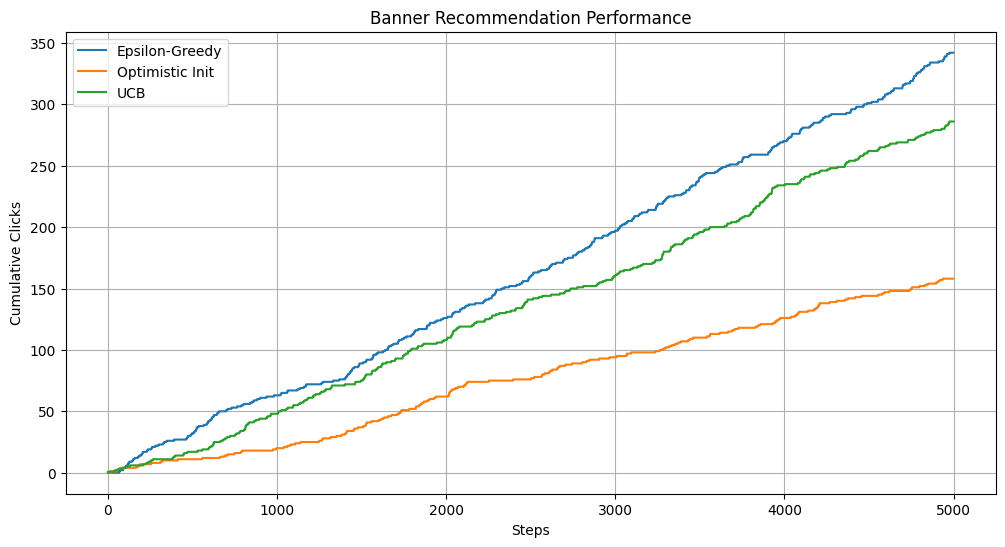

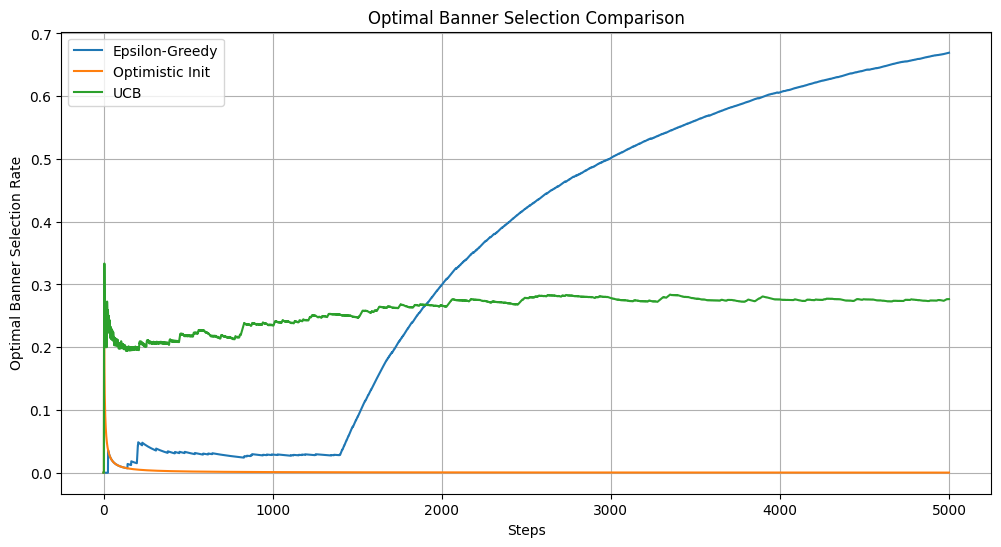


Final Results

Best Banner Arm: 3
Best CTR: 8.00%

Total Clicks:
Epsilon-Greedy: 342
Optimistic Init: 158
UCB: 286

Estimated CTRs:

Epsilon-Greedy:
[0.02840909 0.0576324  0.01098901 0.07650926 0.05825243]

Optimistic Initialization:
[0.0316253 0.        0.        0.        0.       ]

UCB:
[0.03201024 0.05731225 0.04186047 0.08387563 0.05290456]


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# E-Commerce Banner Bandit Environment
# ==========================================

class BannerBandit:

    def __init__(self, ctrs):

        self.ctrs = ctrs
        self.n_arms = len(ctrs)

    def pull(self, arm):

        # Bernoulli reward:
        # 1 = click
        # 0 = no click

        return np.random.binomial(1, self.ctrs[arm])


# ==========================================
# Base Agent
# ==========================================

class BaseAgent:

    def __init__(self, n_arms):

        self.n_arms = n_arms

        self.q_values = np.zeros(n_arms)

        self.action_counts = np.zeros(n_arms)

        self.total_reward = 0

    def update(self, arm, reward):

        self.action_counts[arm] += 1

        n = self.action_counts[arm]

        # Incremental update
        self.q_values[arm] += (
            reward - self.q_values[arm]
        ) / n

        self.total_reward += reward


# ==========================================
# Epsilon-Greedy Agent
# ==========================================

class EpsilonGreedyAgent(BaseAgent):

    def __init__(self, n_arms, epsilon=0.1):

        super().__init__(n_arms)

        self.epsilon = epsilon

    def select_action(self):

        if np.random.rand() < self.epsilon:

            return np.random.randint(self.n_arms)

        return np.argmax(self.q_values)


# ==========================================
# Optimistic Initialization Agent
# ==========================================

class OptimisticAgent(BaseAgent):

    def __init__(self, n_arms, initial_value=5):

        super().__init__(n_arms)

        # Optimistic initialization
        self.q_values = np.ones(n_arms) * initial_value

    def select_action(self):

        return np.argmax(self.q_values)


# ==========================================
# UCB Agent
# ==========================================

class UCBAgent(BaseAgent):

    def __init__(self, n_arms, c=2):

        super().__init__(n_arms)

        self.c = c

        self.total_steps = 0

    def select_action(self):

        self.total_steps += 1

        # Ensure every arm selected once
        for arm in range(self.n_arms):

            if self.action_counts[arm] == 0:

                return arm

        ucb_values = self.q_values + self.c * np.sqrt(
            np.log(self.total_steps)
            / self.action_counts
        )

        return np.argmax(ucb_values)


# ==========================================
# Experiment Runner
# ==========================================

def run_experiment(agent, bandit, steps=5000):

    rewards = []

    optimal_arm = np.argmax(bandit.ctrs)

    optimal_actions = []

    for step in range(steps):

        arm = agent.select_action()

        reward = bandit.pull(arm)

        agent.update(arm, reward)

        rewards.append(reward)

        optimal_actions.append(
            1 if arm == optimal_arm else 0
        )

    cumulative_rewards = np.cumsum(rewards)

    optimal_action_rate = (
        np.cumsum(optimal_actions)
        / (np.arange(steps) + 1)
    )

    return cumulative_rewards, optimal_action_rate


# ==========================================
# Main Experiment
# ==========================================

np.random.seed(42)

# True banner CTRs
# Best banner = index 3

banner_ctrs = [
    0.03,  # Electronics
    0.05,  # Fashion
    0.04,  # Travel
    0.08,  # Cashback
    0.06   # Grocery
]

bandit = BannerBandit(banner_ctrs)

steps = 5000

# Agents
epsilon_agent = EpsilonGreedyAgent(
    n_arms=5,
    epsilon=0.1
)

optimistic_agent = OptimisticAgent(
    n_arms=5,
    initial_value=5
)

ucb_agent = UCBAgent(
    n_arms=5,
    c=2
)

# Run experiments
eps_rewards, eps_optimal = run_experiment(
    epsilon_agent,
    bandit,
    steps
)

opt_rewards, opt_optimal = run_experiment(
    optimistic_agent,
    bandit,
    steps
)

ucb_rewards, ucb_optimal = run_experiment(
    ucb_agent,
    bandit,
    steps
)

# ==========================================
# Plot Cumulative Rewards
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(eps_rewards, label="Epsilon-Greedy")
plt.plot(opt_rewards, label="Optimistic Init")
plt.plot(ucb_rewards, label="UCB")

plt.xlabel("Steps")
plt.ylabel("Cumulative Clicks")

plt.title(
    "Banner Recommendation Performance"
)

plt.legend()

plt.grid(True)

plt.show()


# ==========================================
# Plot Optimal Action %
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(eps_optimal, label="Epsilon-Greedy")
plt.plot(opt_optimal, label="Optimistic Init")
plt.plot(ucb_optimal, label="UCB")

plt.xlabel("Steps")
plt.ylabel("Optimal Banner Selection Rate")

plt.title(
    "Optimal Banner Selection Comparison"
)

plt.legend()

plt.grid(True)

plt.show()


# ==========================================
# Final Results
# ==========================================

print("\n==============================")
print("Final Results")
print("==============================")

print(f"\nBest Banner Arm: {np.argmax(banner_ctrs)}")
print(f"Best CTR: {max(banner_ctrs):.2%}")

print("\nTotal Clicks:")

print(
    f"Epsilon-Greedy: "
    f"{eps_rewards[-1]}"
)

print(
    f"Optimistic Init: "
    f"{opt_rewards[-1]}"
)

print(
    f"UCB: "
    f"{ucb_rewards[-1]}"
)

print("\nEstimated CTRs:\n")

print("Epsilon-Greedy:")
print(epsilon_agent.q_values)

print("\nOptimistic Initialization:")
print(optimistic_agent.q_values)

print("\nUCB:")
print(ucb_agent.q_values)

8. To implement function approximation using linear regression and a shallow neural network for a smart energy management system that predicts future electricity demand based on historical data patterns in a reinforcement
learning context.


Function Approximation Results

Linear Regression MSE: 25.09
Neural Network MSE: 25.78


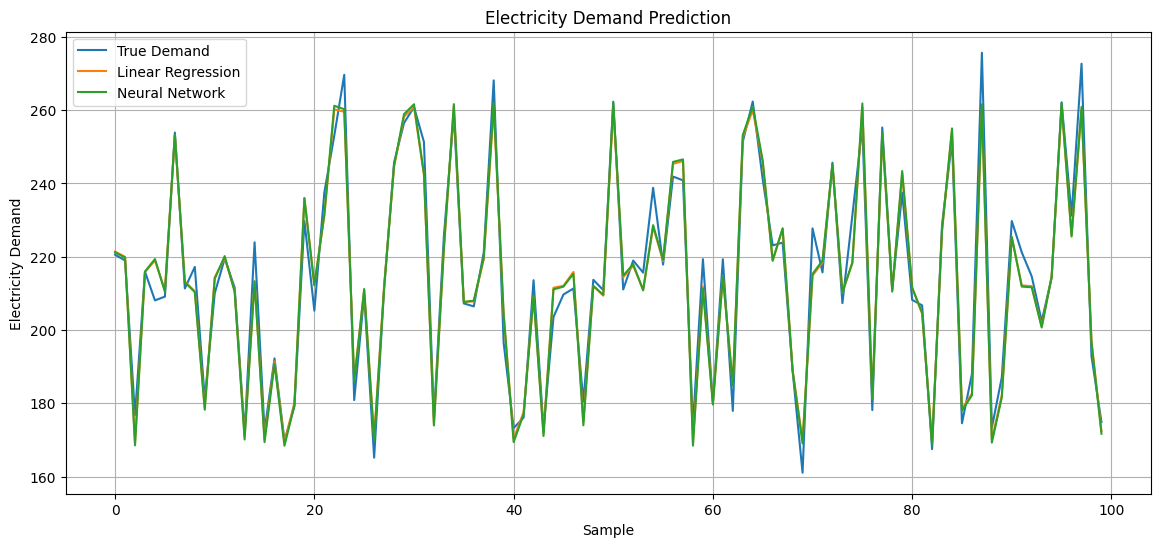


Example TD Learning Update
Old Value Estimate: 120
Updated Value Estimate: 119.20


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

# ==========================================
# Generate Synthetic Smart Grid Data
# ==========================================

np.random.seed(42)

hours = np.arange(0, 2000)

# Simulated features
temperature = 20 + 10 * np.sin(hours / 24)

previous_demand = 50 + 15 * np.sin(hours / 12)

time_of_day = hours % 24

# Simulated electricity demand
demand = (
    100
    + 2 * temperature
    + 1.5 * previous_demand
    + 10 * np.sin(hours / 24)
    + np.random.normal(0, 5, len(hours))
)

# ==========================================
# Create Dataset
# ==========================================

data = pd.DataFrame({
    "temperature": temperature,
    "previous_demand": previous_demand,
    "time_of_day": time_of_day,
    "target_demand": demand
})

# Features and target
X = data[
    ["temperature", "previous_demand", "time_of_day"]
]

y = data["target_demand"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Linear Regression Approximation
# ==========================================

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

# ==========================================
# Shallow Neural Network Approximation
# ==========================================

nn_model = MLPRegressor(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

nn_model.fit(X_train, y_train)

nn_predictions = nn_model.predict(X_test)

nn_mse = mean_squared_error(
    y_test,
    nn_predictions
)

# ==========================================
# Results
# ==========================================

print("\n==============================")
print("Function Approximation Results")
print("==============================")

print(f"\nLinear Regression MSE: {linear_mse:.2f}")

print(f"Neural Network MSE: {nn_mse:.2f}")

# ==========================================
# Plot Predictions
# ==========================================

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values[:100],
    label="True Demand"
)

plt.plot(
    linear_predictions[:100],
    label="Linear Regression"
)

plt.plot(
    nn_predictions[:100],
    label="Neural Network"
)

plt.xlabel("Sample")

plt.ylabel("Electricity Demand")

plt.title(
    "Electricity Demand Prediction"
)

plt.legend()

plt.grid(True)

plt.show()

# ==========================================
# RL-style TD Update Example
# ==========================================

print("\n==============================")
print("Example TD Learning Update")
print("==============================")

alpha = 0.1
gamma = 0.9

# Example current estimate
V_s = 120

reward = -5

V_next = 130

# TD update
updated_value = V_s + alpha * (
    reward
    + gamma * V_next
    - V_s
)

print(f"Old Value Estimate: {V_s}")

print(f"Updated Value Estimate: {updated_value:.2f}")